In [1]:
## After installing Scanpy and matplotlib to your fresh environment from anaconda prompt, import both modules:
from __future__ import annotations

import scanpy as sc
from matplotlib.pyplot import rc_context

## define parameters for plotting
sc.set_figure_params(dpi=100, color_map="viridis_r")
sc.settings.verbosity = 0
sc.logging.print_header()


/var/folders/1v/z7159g391sd3b__mmrk2g4kh0000gn/T/ipykernel_46294/3037603700.py:10: RuntimeWarning: Failed to import dependencies for application/vnd.jupyter.widget-view+json representation. (ModuleNotFoundError: No module named 'ipywidgets')
  sc.logging.print_header()


Package,Version
scanpy,1.12
matplotlib,3.10.8
Component,Info
Python,"3.14.3 | packaged by conda-forge | (main, Feb 9 2026, 22:17:37) [Clang 20.1.8 ]"
OS,macOS-26.3.1-x86_64-i386-64bit-Mach-O
CPU,"8 logical CPU cores, i386"
GPU,No GPU found
Updated,2026-03-16 17:31
Dependency,Version
tornado,6.5.4


In [2]:

## load the tutorial dataset. We will be using the human PBMC dataset. This dataset has been preprocessed and reduced in size for convenience

pbmc = sc.datasets.pbmc68k_reduced()

# inspect the layers of the AnnData object. What layer are your feature/gene counts stored in?
pbmc

AnnData object with n_obs × n_vars = 700 × 765
    obs: 'bulk_labels', 'n_genes', 'percent_mito', 'n_counts', 'S_score', 'G2M_score', 'phase', 'louvain'
    var: 'n_counts', 'means', 'dispersions', 'dispersions_norm', 'highly_variable'
    uns: 'bulk_labels_colors', 'louvain', 'louvain_colors', 'neighbors', 'pca', 'rank_genes_groups'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

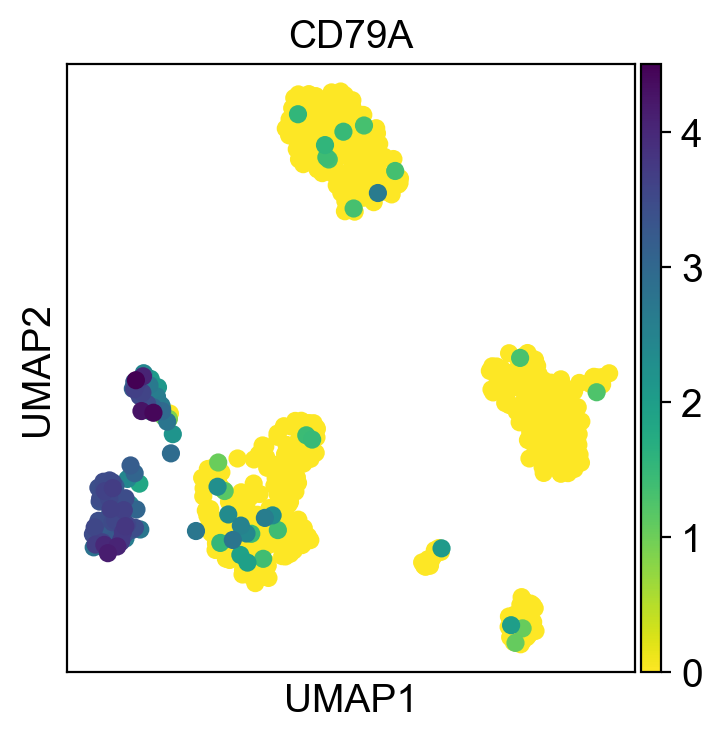

In [3]:
## An important base function in sc transcriptomic analysis is to display the expression of a feature/gene
## by cluster in UMAP space
## The shell code for this function looks like this:
# rc_context is used for the figure size, in this case 4x4
with rc_context({"figure.figsize": (4, 4)}):
    sc.pl.umap(pbmc, color="CD79A")


KeyError: 'IL6'

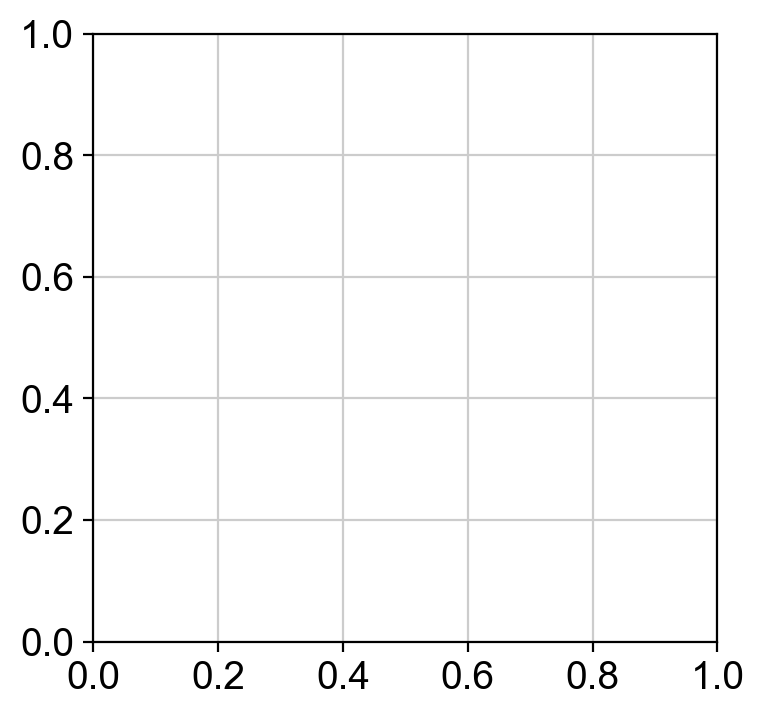

In [4]:
## The above code simply assigns the 'color' variable to the fold expression of our marker gene for the CD79A annotated cluster
## As we expect, it is expressed highly in the CD79A cluster, and at relatively low levels elsewhere
# what if you were to output a scatterplot showing the expression of a non-marker gene IL6  in UMAP space?
### **Omit this answer from student version

# again, rc_context is used for the figure size, in this case 4x4
with rc_context({"figure.figsize": (4, 4)}):
    sc.pl.umap(pbmc, color="IL6")


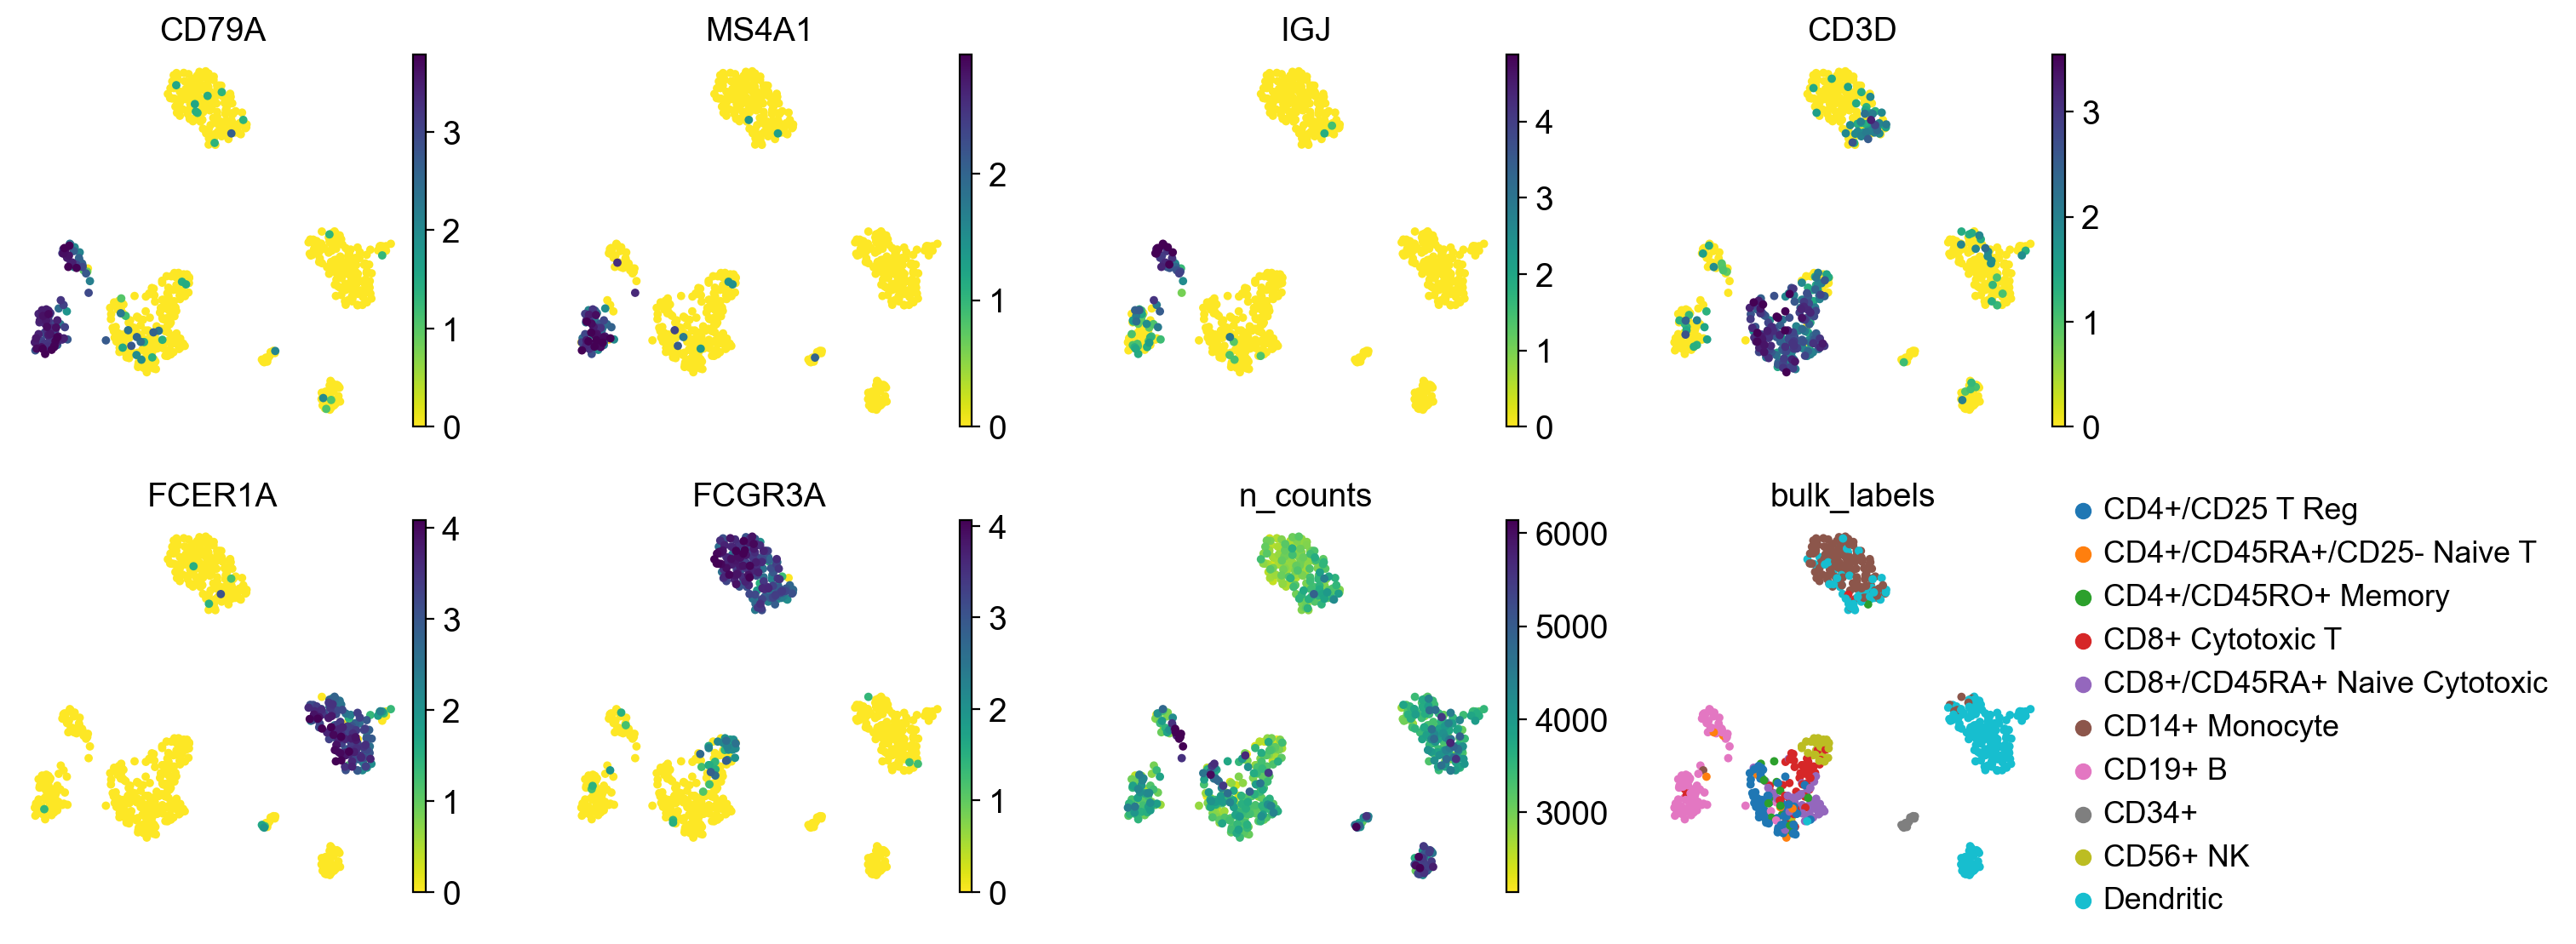

In [5]:
## The scatterplot function is versitile, and not limited to plotting expression or markers in UMAP space
## For instance, we can generate a plot with our color variable assigned to celltype annotations from this dataset's metadata,
## multiple markers, and gene counts (a fairly silly metric to plot in this way).
color_vars = [
    "CD79A",
    "MS4A1",
    "IGJ",
    "CD3D",
    "FCER1A",
    "FCGR3A",
    "n_counts",
    "bulk_labels",
]
with rc_context({"figure.figsize": (3, 3)}):
    sc.pl.umap(pbmc, color=color_vars, s=50, frameon=False, ncols=4, vmax="p99")


In [6]:
## Before we go futher, let's take our cluster markers and make some proper celltype annotations for our data:
marker_genes_dict = {
    "B-cell": ["CD79A", "MS4A1"],
    "Dendritic": ["FCER1A", "CST3"],
    "Monocytes": ["FCGR3A"],
    "NK": ["GNLY", "NKG7"],
    "Other": ["IGLL1"],
    "Plasma": ["IGJ"],
    "T-cell": ["CD3D"],
}


In [7]:
## Now let's move on to some data visuzlization strategies to help us compare population expression magnitude between multiple clusters
## One approach to this is the dotplot
## The basic format for generating a dotplot in Scanpy is:
sc.pl.dotplot(pbmc, marker_genes_dict, "clusters", dendrogram=True)



ValueError: groupby has to be a valid observation. Given clusters, is not in observations: ['bulk_labels', 'n_genes', 'percent_mito', 'n_counts', 'S_score', 'G2M_score', 'phase', 'louvain']  or index name "index"

In [8]:
## Here we are just refining our annotations based on the exclusivity of marker expression
# create a dictionary to map cluster to annotation label
cluster2annotation = {
    "0": "Monocytes",
    "1": "NK",
    "2": "T-cell",
    "3": "Dendritic",
    "4": "Dendritic",
    "5": "Plasma",
    "6": "B-cell",
    "7": "Dendritic",
    "8": "Other",
}


In [9]:
# add a new `.obs` column called `cell type` by mapping clusters to annotation using pandas `map` function
pbmc.obs["cell type"] = pbmc.obs["clusters"].map(cluster2annotation).astype("category")


KeyError: 'clusters'

In [10]:
## Now let's look at the marker dotplot again:
sc.pl.dotplot(pbmc, marker_genes_dict, "cell type", dendrogram=True)


ValueError: groupby has to be a valid observation. Given cell type, is not in observations: ['bulk_labels', 'n_genes', 'percent_mito', 'n_counts', 'S_score', 'G2M_score', 'phase', 'louvain']  or index name "index"

In [11]:
## What if we want to compare expression of a gene of interest accross these clusters?
# first, define our genes to plot:

goi.interleukin = ['IL37', 'IL35', 'IL21', 'CX3CR1', 'TPT1', 'TCF7']

sc.pl.dotplot(pbmc, goi.interleukin, "cell type", dendrogram=True)


NameError: name 'goi' is not defined

In [12]:
## How about your favorite gene of interest? How would you create a dotplot to see its cluster-level expression in immune cells?
## remove the below from student notebook:
mynewgoi = ['insert fav genes here']

sc.pl.dotplot(pbmc, mynewgoi, "cell type", dendrogram=True)


ValueError: groupby has to be a valid observation. Given cell type, is not in observations: ['bulk_labels', 'n_genes', 'percent_mito', 'n_counts', 'S_score', 'G2M_score', 'phase', 'louvain']  or index name "index"

In [13]:
## Dotplots are fantastic to look at an overview of transcriptome patterns at the population level, but what if you want a 
## survey of what expression looks like for your gene of interest from cell to cell?

## Here we can employ a heatmap, which outputs a dense matrix plot showing the fold expression (or log fold change if comparing two conditions!)
## of a gene of interest in each cluster.
# the basic format for making a heatmap in Scanpy is:
sc.pl.heatmap(pbmc, marker_genes_dict,"cell type" , swap_axes=True)


ValueError: groupby has to be a valid observation. Given cell type, is not in observations: ['bulk_labels', 'n_genes', 'percent_mito', 'n_counts', 'S_score', 'G2M_score', 'phase', 'louvain']  or index name "index"

In [14]:
## Notice this is just plotting our cluster markers, but it still gives a sense of the interclustal heterogeneity,
## even in features that we used to define our clusters identity.
# also, we flipped it 90 degrees using swap_axes to make it less horrid to read. If your Y-axis variable (for heatmaps, the clusters you wish to interrogate)
# is shorter, there is no need to do this

## What if I wanted to make a heatmap comparing the transcriptional heterogeneity of our interleukin-related genes of interest from earlier?
# Omit this answer from the student copy
sc.pl.heatmap(pbmc, goi.interleukin,"cell type" , swap_axes=True)


NameError: name 'goi' is not defined

In [ ]:













## Curious about your favorite gene of interest in a particular cluster? Try making a new dictionary for your gene and running the same code to make a plot






In [ ]:
## Great job mastering the basics of plotting SC transcriptome data with scanpy.
## Follow this link to see a tutorial for a (more time consuming) vignette I'd like to touch on quickly-
## RNA velocity modeling: https://scanpy.readthedocs.io/en/stable/tutorials/trajectories/paga-paul15.html
